# SRCS TVAC2 Results Analysis

This notebook presents the results of the WFI/SRCS TVAC2 testing. It reads in an H5 file containing a DataFrame with distilled results from LED activation events during the test.

# DataFrame Columns Documentation

- **time**: Timestamp
- **setname**: Name of the dataset
- **comment**: Additional comments
- **5to30, 5to60, 5to90, 15to90, 60to160, 60to300, 60to360, 15to315**: % settling for Various time intervals for measurements
- **5to-1, 15to-1**: Specific time intervals, -1 means to the last second of available data
- **pd1, pd2**: Photodiode 1 and 2 dark corrected measurement average
- **pd1 [no corr], pd2 [no corr]**: Uncorrected photodiode measurements
- **pd1 err, pd2 err**: std dev error values for photodiodes
- **pd1 min, pd1 max, pd2 min, pd2 max**: Min and max values for photodiodes
- **pd1 [uV rms], pd2 [uV rms]**: RMS values for photodiodes in microvolts
- **dark pd1, dark pd2**: Dark measurements for photodiodes
- **dark pd1 [uV rms], dark pd2 [uV rms]**: RMS values for dark current in microvolts
- **used [s], used [s*mA]**: Usage metrics
- **HTR [%]**: Heater percentage
- **side**: Side indicator
- **start, end**: Start and end times
- **band, bank**: Band and bank information
- **ctrlv, ctrlv err, ctrlv min, ctrlv max**: Control voltage and related metrics
- **current**: programmed current
- **mcurrent**: telemetered current measurements, only valid in low range
- **code**: Code identifier
- **ledfv, ledfv err, ledfv min, ledfv max**: LED forward voltage and related metrics
- **pd1gain, pd2gain**: Gain settings for photodiodes
- **pd1LTP[mA], pd2LTP[mA]**: LTP values for photodiodes in milliamps
- **pd1bias[mV], pd2bias[mV]**: Bias voltages for photodiodes in millivolts
- **sphere, board**: Sphere and board temperature [K]
- **loopback**: Loopback indicator
- **exp**: exposure
- **activity**: Activity #
- **OTP**: OTP (Optical Test Procedure) information
- **PD1 data, PD2 data**: Dark corrected photodiode time series data

## How to read in data

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

results = pd.read_hdf('tvac2results.h5', 'data')
results

,time,setname,comment,5to30,5to60,5to90,15to90,60to160,60to300,60to360,...,pd1bias[mV],pd2bias[mV],sphere,board,loopback,exp,activity,OTP,PD1 data,PD2 data
0,2024-04-05 19:31:51.457000000,,WFI TV1||Sphere@200K|sRCSE@244K,5.7959,7.9828,9.2878,5.6934,3.4886,5.9570,NaN,...,112.5,112.5,200.257103,244.456291,0.0,0,0,0,time 2024-04-05 19:31:51.457 0.001383 2024-...,time 2024-04-05 19:31:51.457 0.000370 2024-...
1,2024-04-05 19:37:24.447000000,,WFI TV1||Sphere@200K|sRCSE@244K,5.8611,8.0187,9.3270,5.6724,3.2234,5.6398,NaN,...,112.5,112.5,200.257103,244.458156,0.0,0,0,0,time 2024-04-05 19:37:24.447 0.001332 2024-...,time 2024-04-05 19:37:24.447 0.000368 2024-...
2,2024-04-05 19:42:56.398000000,,WFI TV1||Sphere@200K|sRCSE@244K,1.1891,1.7266,2.0722,1.4479,0.8289,1.4587,NaN,...,112.5,112.5,200.257103,244.460437,0.0,0,0,0,time 2024-04-05 19:42:56.398 0.013284 2024-...,time 2024-04-05 19:42:56.398 0.011094 2024-...
3,2024-04-05 19:48:32.406000000,,WFI TV1||Sphere@200K|sRCSE@244K,1.2106,1.9136,2.3046,1.6599,0.9512,1.5358,NaN,...,112.5,112.5,200.256766,244.461058,0.0,0,0,0,time 2024-04-05 19:48:32.406 0.013086 2024-...,time 2024-04-05 19:48:32.406 0.010995 2024-...
4,2024-04-05 19:54:06.345000000,,WFI TV1||Sphere@200K|sRCSE@244K,0.5245,0.7343,0.8507,0.5646,0.3242,0.5703,NaN,...,112.5,112.5,200.256766,244.462095,0.0,0,0,0,time 2024-04-05 19:54:06.345 0.002688 2024-...,time 2024-04-05 19:54:06.345 0.008217 2024-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2061,2024-05-12 15:53:00.979000000,,WFI TV1||Sphere@200K|sRCSE@253K,2.4503,3.1544,3.5493,1.9935,NaN,NaN,NaN,...,112.5,112.5,200.372909,253.269300,1907.0,883,1,0,time 2024-05-12 15:53:00.979 -0.001165 2024-...,time 2024-05-12 15:53:00.979 -0.000203 2024-...
2062,2024-05-12 15:54:38.908000000,,WFI TV1||Sphere@200K|sRCSE@253K,0.2044,0.3358,0.3163,0.1655,NaN,NaN,NaN,...,112.5,112.5,200.373582,253.267613,1908.0,884,1,0,time 2024-05-12 15:54:38.908 -0.001164 2024-...,time 2024-05-12 15:54:38.908 -0.000202 2024-...
2063,2024-05-12 15:56:15.899000000,,WFI TV1||Sphere@200K|sRCSE@253K,0.2109,0.3335,0.3972,0.2109,NaN,NaN,NaN,...,112.5,112.5,200.374592,253.267192,1908.0,884,1,0,time 2024-05-12 15:56:15.899 -0.001163 2024-...,time 2024-05-12 15:56:15.899 -0.000200 2024-...
2064,2024-05-12 15:57:51.966000000,,WFI TV1||Sphere@200K|sRCSE@253K,0.6481,NaN,NaN,NaN,NaN,NaN,NaN,...,112.5,112.5,200.374929,253.266032,1909.0,885,1,0,time 2024-05-12 15:57:51.966000000 -0.001165...,time 2024-05-12 15:57:51.966000000 -0.000201...


# How to get side B band 4 bank 1

In [3]:
r = results
b = r[(r.band == 5) & (r.bank == 1) & (r.side == 'B')].copy()
b[['time', 'side', 'band', 'bank', 'current', 'ledfv', 'pd1', 'pd2', 'PD2 data']]

,time,side,band,bank,current,ledfv,pd1,pd2,PD2 data
2,2024-04-05 19:42:56.398000000,B,5,1,0.000117,0.817218,0.010403,0.008229,time 2024-04-05 19:42:56.398 0.011094 2024-...
10,2024-04-05 20:17:25.293000000,B,5,1,0.000060,0.791387,0.005527,0.004007,time 2024-04-05 20:17:25.293 0.000545 2024-...
11,2024-04-05 20:18:07.340000000,B,5,1,0.000002,0.662300,0.001396,0.000416,time 2024-04-05 20:18:07.340 0.004009 2024-...
22,2024-04-05 20:54:55.199000000,B,5,1,0.003878,0.973606,0.364745,0.312991,time 2024-04-05 20:54:55.199 0.011371 2024-...
23,2024-04-05 20:55:32.147000000,B,5,1,0.000117,0.817792,0.010532,0.008343,time 2024-04-05 20:55:32.147 0.313416 2024-...
...,...,...,...,...,...,...,...,...,...
2016,2024-05-12 14:52:14.147000000,B,5,1,0.039989,1.150048,-2.143071,-2.172726,time 2024-05-12 14:52:14.147000000 -2.386131...
2028,2024-05-12 15:09:26.004000000,B,5,1,0.000200,0.856856,0.016848,0.015444,time 2024-05-12 15:09:26.004000000 -0.000204...
2040,2024-05-12 15:26:52.026000001,B,5,1,0.000150,0.836408,0.012017,0.011259,time 2024-05-12 15:26:52.026000001 -0.000203...
2052,2024-05-12 15:42:23.932000000,B,5,1,0.000100,0.813848,0.007350,0.007208,time 2024-05-12 15:42:23.932000000 -0.000204...


# Plotting some of the time series for fun

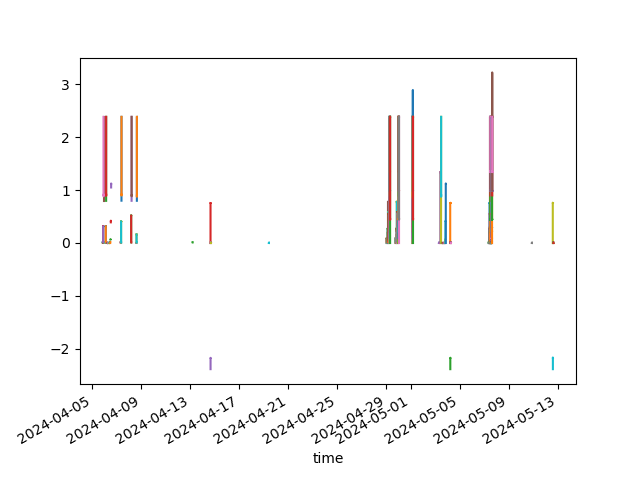

In [4]:
plt.figure()
for i in range(len(b)):
    b.iloc[i]['PD2 data'].plot()

In [6]:
plt.plot(b.iloc[i]['PD2 data'])

# Cumulative sum exampless 
This cell performs the following operations:
1. Converts milliampere-seconds to ampere-seconds
2. Calculates cumulative sums for various metrics
3. Computes relaxation time between starts in days
4. Calculates cumulative relaxation time

In [4]:

b['used [s*A]'] = b['used [s*mA]']/1e3
b['used sum [s*mA]'] = b['used [s*mA]'].cumsum()
b['used sum [s*A]'] = b['used [s*A]'].cumsum()
b['used sum [s]'] = b['used [s]'].cumsum()
b['relax'] = b['start'].diff().dt.total_seconds()/(60*60*24)
b['relax sum [days]'] = b['relax'].cumsum()

b[['time', 'side', 'band', 'bank', 'used [s*A]', 'used sum [s*mA]', 'used sum [s*A]', 'used sum [s]', 'relax', 'relax sum [days]']]


,time,side,band,bank,used [s*A],used sum [s*mA],used sum [s*A],used sum [s],relax,relax sum [days]
0,2024-04-05 19:31:51.457000000,B,4,1,0.049460,49.460020,0.049460,320.962,NaN,NaN
6,2024-04-05 20:05:03.383000000,B,4,1,0.010493,59.952566,0.059953,358.888,0.023056,0.023056
7,2024-04-05 20:05:41.309000000,B,4,1,0.001623,61.576042,0.061576,675.868,0.000440,0.023495
18,2024-04-05 20:42:16.250000000,B,4,1,0.367514,429.090418,0.429090,718.850,0.025405,0.048900
19,2024-04-05 20:42:59.232000000,B,4,1,0.049153,478.243626,0.478244,1037.821,0.000498,0.049398
...,...,...,...,...,...,...,...,...,...,...
2012,2024-05-12 14:47:06.115000000,B,4,1,2.917615,304646.231299,304.646231,23956.139,0.008322,36.802257
2024,2024-05-12 15:01:00.034000000,B,4,1,0.030598,304676.829485,304.676829,24109.145,0.009653,36.811910
2036,2024-05-12 15:20:27.019000000,B,4,1,0.014073,304690.902949,304.690903,24203.129,0.013507,36.825417
2048,2024-05-12 15:35:59.026000001,B,4,1,0.009400,304700.303053,304.700303,24297.115,0.010787,36.836204
